# 09 · Inference and Model Audit

Use the saved models as the app does, then check them:

1. single and batch prediction
2. input validation
3. behaviour checks
4. subgroup performance
5. results without the 107 flagged rows

In [1]:
import sys, warnings, time, json
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from sksurv.metrics import concordance_index_censored

from seer_survival import config as C
from seer_survival.data import load_clean, consistency_flags
from seer_survival.inference import SeerPredictor
from seer_survival.targets import horizon_label
from seer_survival.training import make_split
from seer_survival.plots import set_style, save_fig, PALETTE

set_style()
pred = SeerPredictor.load()
meta = pred.metadata
print(json.dumps({k: meta[k] for k in ["classifier_name", "survival_model_name", "threshold", "risk_group_cutoffs",
                                        "trained_at_utc", "scikit_learn", "n_train", "n_test"]}, indent=2))

{
  "classifier_name": "LogReg (L1)",
  "survival_model_name": "Coxnet (elastic net)",
  "threshold": 0.14736129419109817,
  "risk_group_cutoffs": [
    0.07008988943653278,
    0.13966250415176273
  ],
  "trained_at_utc": "2026-09-25 19:33",
  "scikit_learn": "1.5.2",
  "n_train": 3219,
  "n_test": 805
}


## 1. Single-patient inference

In [2]:
patients = pd.DataFrame([
    {"age": 48, "race": "White", "marital_status": "Married", "t_stage": "T1", "n_stage": "N1", "grade": 1,
     "a_stage": "Regional", "tumor_size": 15, "estrogen_status": "Positive", "progesterone_status": "Positive",
     "nodes_examined": 18, "nodes_positive": 1},
    {"age": 58, "race": "White", "marital_status": "Divorced", "t_stage": "T2", "n_stage": "N2", "grade": 2,
     "a_stage": "Regional", "tumor_size": 35, "estrogen_status": "Positive", "progesterone_status": "Negative",
     "nodes_examined": 14, "nodes_positive": 6},
    {"age": 66, "race": "Black", "marital_status": "Widowed", "t_stage": "T3", "n_stage": "N3", "grade": 3,
     "a_stage": "Regional", "tumor_size": 70, "estrogen_status": "Negative", "progesterone_status": "Negative",
     "nodes_examined": 16, "nodes_positive": 14},
], index=["Patient A (early)", "Patient B (intermediate)", "Patient C (advanced)"])
out = pred.predict(patients)
out.round(3)

,risk_5y,risk_group,flag_high_risk,survival_36m,survival_60m,survival_84m
Patient A (early),0.031,Low,0,0.987,0.972,0.958
Patient B (intermediate),0.276,High,1,0.906,0.806,0.727
Patient C (advanced),0.833,High,1,0.527,0.246,0.126


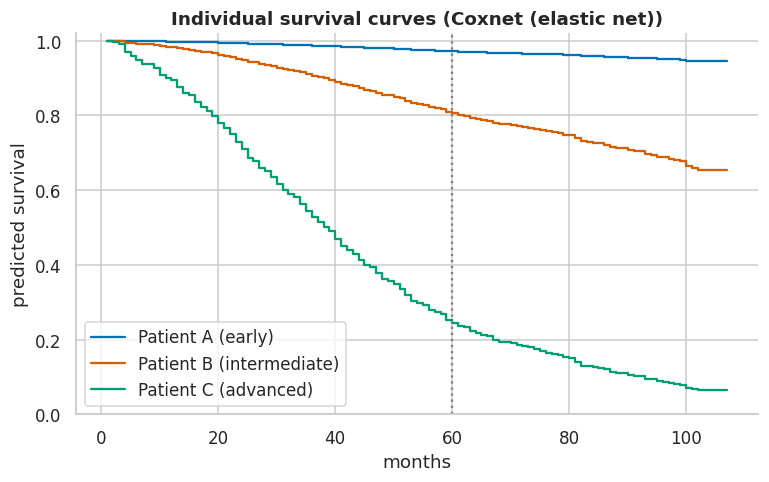

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, (name, row) in enumerate(patients.iterrows()):
    curve = pred.survival_curve(row.to_frame().T)
    ax.step(curve.month, curve.survival, where="post", c=PALETTE[i], label=name)
ax.axvline(60, ls=":", c="grey"); ax.set_ylim(0, 1.02); ax.set_xlabel("months"); ax.set_ylabel("predicted survival")
ax.set_title(f"Individual survival curves ({meta['survival_model_name']})"); ax.legend()
save_fig(fig, "09_example_survival_curves"); plt.show()

### Local explanation (feature occlusion)

In [4]:
pred.explain(patients.iloc[[2]]).round(4)

,feature,value,reference,contribution
11,nodes_positive,14,2.0,0.1573
8,estrogen_status,Negative,Positive,0.1397
4,n_stage,N3,N1,0.1030
9,progesterone_status,Negative,Positive,0.0922
5,grade,3,2,0.0500
1,race,Black,White,0.0440
7,tumor_size,70,25.0,0.0423
0,age,66,54.0,0.0368
2,marital_status,Widowed,Married,0.0277
10,nodes_examined,16,14.0,-0.0161


## 2. Input validation

In [5]:
bad_cases = {
    "invalid category": {**patients.iloc[0].to_dict(), "t_stage": "T5"},
    "positive > examined": {**patients.iloc[0].to_dict(), "nodes_positive": 40},
    "non-numeric age": {**patients.iloc[0].to_dict(), "age": "fifty"},
}
for label, rec in bad_cases.items():
    try:
        pred.predict(pd.DataFrame([rec]))
        print(f"{label:22s} -> NOT caught (problem!)")
    except ValueError as e:
        print(f"{label:22s} -> rejected: {e}")

w = pred.predict(pd.DataFrame([{**patients.iloc[0].to_dict(), "age": 82}])).attrs["warnings"]
print("\nage 82 (outside 30-69 training range) -> warnings:", w)

invalid category       -> rejected: 't_stage' has invalid values ['T5']; allowed: ['T1', 'T2', 'T3', 'T4']
positive > examined    -> rejected: nodes_positive cannot exceed nodes_examined
non-numeric age        -> rejected: 'age' must be numeric (rows [0])

age 82 (outside 30-69 training range) -> warnings: ['age outside training range [30, 69] - prediction is an extrapolation']


## 3. Batch inference on the held-out test split

In [6]:
df = load_clean()
s = make_split(df)
test = df.iloc[s["idx_test"]].reset_index(drop=True)
t0 = time.perf_counter()
bp = pred.predict(test)
elapsed = time.perf_counter() - t0
print(f"{len(test)} patients scored in {elapsed:.2f}s ({elapsed / len(test) * 1000:.2f} ms/patient)")
preds = pd.concat([test, bp], axis=1)
preds.to_csv(C.TABLES_DIR / "test_predictions.csv", index=False)
preds[["age", "t_stage", "n_stage", "grade", "status", "survival_months", "risk_5y", "risk_group", "survival_60m"]].head()

805 patients scored in 0.05s (0.06 ms/patient)


,age,t_stage,n_stage,grade,status,survival_months,risk_5y,risk_group,survival_60m
0,67,T2,N1,2,Alive,50,0.082912,Intermediate,0.923750
1,49,T1,N3,1,Dead,14,0.252766,High,0.894283
2,56,T3,N1,2,Alive,98,0.077631,Intermediate,0.922040
3,51,T2,N1,2,Alive,67,0.068693,Low,0.941759
4,46,T1,N1,3,Alive,100,0.119632,Intermediate,0.867509


## 4. Behaviour checks

In [7]:
checks = {}
checks["survival non-increasing in time"] = bool(((bp.survival_36m >= bp.survival_60m) & (bp.survival_60m >= bp.survival_84m)).all())
checks["risk in (0, 1)"] = bool(bp.risk_5y.between(0, 1, inclusive="neither").all())
# 5-year risk from classifier vs 1 - S(60) from survival model: two independent models, should agree in ranking
checks["classifier vs survival model rank agreement (Spearman)"] = round(bp.risk_5y.corr(1 - bp.survival_60m, method="spearman"), 3)
# monotonicity: increasing positive nodes should not decrease risk
base = patients.iloc[[1]].copy()
risks = []
for k in range(1, 15):
    b = base.copy(); b["nodes_positive"] = k
    risks.append(pred.predict(b).risk_5y.iloc[0])
checks["risk non-decreasing in nodes_positive (1..14)"] = bool(np.all(np.diff(risks) >= -1e-9))
pd.Series(checks)

survival non-increasing in time                            True
risk in (0, 1)                                             True
classifier vs survival model rank agreement (Spearman)    0.942
risk non-decreasing in nodes_positive (1..14)              True
dtype: object

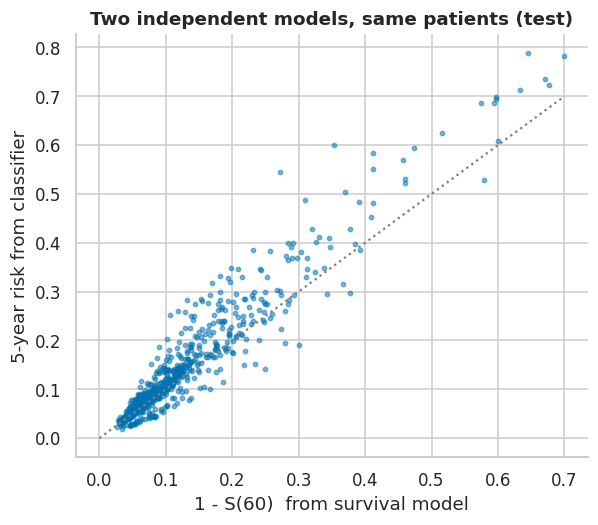

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(1 - bp.survival_60m, bp.risk_5y, s=8, alpha=.5, c=PALETTE[0])
ax.plot([0, .7], [0, .7], ls=":", c="grey")
ax.set_xlabel("1 - S(60)  from survival model"); ax.set_ylabel("5-year risk from classifier")
ax.set_title("Two independent models, same patients (test)")
save_fig(fig, "09_model_agreement"); plt.show()

## 5. Subgroups

C-index (survival model), AUC (classifier) and observed minus predicted 5-year risk for each subgroup. Small groups are uncertain, so event counts are shown.

In [9]:
test["age_group"] = pd.cut(test.age, [29, 49, 59, 69], labels=["30-49", "50-59", "60-69"])
test["hr"] = np.where((test.estrogen_status == "Negative") & (test.progesterone_status == "Negative"), "ER-/PR-", "ER+ or PR+")
y5, known = horizon_label(test.survival_months, test.event)
risk_surv = pred.survival.predict(test[pred.metadata["input_columns"]])
rows = []
for col in ["race", "age_group", "stage_6th", "hr"]:
    for lv in sorted(test[col].dropna().unique(), key=str):
        m = (test[col] == lv).to_numpy()
        mk = m & known
        row = {"variable": col, "group": lv, "n": int(m.sum()), "events": int(test.event[m].sum())}
        row["C-index"] = concordance_index_censored(test.event[m].astype(bool), test.survival_months[m], risk_surv[m])[0] if test.event[m].sum() >= 5 else np.nan
        if y5[mk].sum() >= 5 and (y5[mk] == 0).sum() >= 5:
            row["AUC (5y)"] = roc_auc_score(y5[mk], bp.risk_5y[mk])
        row["obs - pred 5y risk"] = y5[mk].mean() - bp.risk_5y[mk].mean() if mk.sum() else np.nan
        rows.append(row)
audit = pd.DataFrame(rows)
audit.round(3)

,variable,group,n,events,C-index,AUC (5y),obs - pred 5y risk
0,race,Black,63,18,0.678,0.711,0.073
1,race,Other,62,8,0.667,0.670,0.033
2,race,White,680,97,0.713,0.729,-0.013
3,age_group,30-49,259,32,0.710,0.745,0.002
4,age_group,50-59,277,40,0.795,0.801,-0.029
5,age_group,60-69,269,51,0.640,0.658,0.019
6,stage_6th,IIA,261,21,0.619,0.640,-0.010
7,stage_6th,IIB,239,29,0.664,0.624,0.021
8,stage_6th,IIIA,202,36,0.695,0.780,-0.023
9,stage_6th,IIIB,17,7,0.600,0.709,0.103


## 6. Sensitivity analysis: excluding clinically flagged rows

The 107 rows with T-size or N-count inconsistencies (notebook 02) are dropped from **both** training and test. The same models are refit to see whether conclusions change.

In [10]:
from seer_survival.training import horizon_subset, fit_final_classifier, fit_final_survival
from seer_survival.targets import make_surv
from seer_survival.evaluate import survival_metrics

flag = consistency_flags(df).any(axis=1).to_numpy()
keep_tr = ~flag[s["idx_train"]]; keep_te = ~flag[s["idx_test"]]
Xtr, Xte = s["X_train"][keep_tr].reset_index(drop=True), s["X_test"][keep_te].reset_index(drop=True)
ttr, etr, tte, ete = s["t_train"][keep_tr], s["e_train"][keep_tr], s["t_test"][keep_te], s["e_test"][keep_te]
Xh, yh, _ = horizon_subset(Xtr, ttr, etr); Xth, yth, _ = horizon_subset(Xte, tte, ete)
auc_sens = roc_auc_score(yth, fit_final_classifier(meta["classifier_name"], Xh, yh).predict_proba(Xth)[:, 1])
sm = fit_final_survival(meta["survival_model_name"], Xtr, ttr, etr)
c_sens = survival_metrics(sm, Xte, make_surv(ttr, etr), make_surv(tte, ete), np.array(C.EVAL_TIMES, float))["c_harrell"]
pd.DataFrame({
    "all rows": [meta["test_metrics_classifier"]["roc_auc"], meta["test_metrics_survival"]["c_harrell"]],
    "flagged rows removed": [auc_sens, c_sens],
}, index=["classifier test AUC", "survival test C-index"]).round(4)

,all rows,flagged rows removed
classifier test AUC,0.7336,0.7286
survival test C-index,0.7115,0.7081


### How certain is the largest subgroup miscalibration?

In [11]:
rng = np.random.default_rng(C.RANDOM_STATE)
rows = []
for lv in ["Black", "Other", "White"]:
    mk = ((test.race == lv).to_numpy()) & known
    yy, pp = y5[mk], bp.risk_5y.to_numpy()[mk]
    diffs = [yy[i].mean() - pp[i].mean() for i in (rng.integers(0, mk.sum(), mk.sum()) for _ in range(2000))]
    rows.append({"race": lv, "labelled n": int(mk.sum()), "deaths <=60m": int(yy.sum()),
                 "observed rate": yy.mean(), "mean predicted": pp.mean(),
                 "diff 95% CI": f"[{np.percentile(diffs, 2.5):+.3f}, {np.percentile(diffs, 97.5):+.3f}]"})
pd.DataFrame(rows).round(3)

,race,labelled n,deaths <=60m,observed rate,mean predicted,diff 95% CI
0,Black,54,15,0.278,0.205,"[-0.044, +0.195]"
1,Other,50,6,0.120,0.087,"[-0.045, +0.131]"
2,White,553,71,0.128,0.141,"[-0.040, +0.013]"


## Findings

- Invalid inputs are rejected; ages outside 30–69 trigger a warning.
- 805 patients are scored in 0.05 s.
- Survival never increases over time, and risk never falls as positive nodes increase. The two models rank patients almost identically (Spearman 0.94).
- **Black patients:** observed 27.8 % vs predicted 20.5 % 5-year mortality (54 patients, 15 deaths). The 95 % CI (−4.4 to +19.5 points) includes zero, so this needs a larger sample to confirm.
- **Age 60–69:** lower C-index (0.64). Deaths from other causes may explain this, since the outcome is all-cause death.
- Within a single stage group the C-index is lower (0.60–0.71), as expected.
- Removing the 107 flagged rows changes test AUC by −0.005 and C-index by −0.003.
- Risk groups are training-set tertiles, not clinical thresholds.